De waarden voor het exponentieel verband zijn bepaald op a = 0.0025 +/- 0.0005, b = 0.42 +/- 0.01 en c = 0.03 +/- 0.02


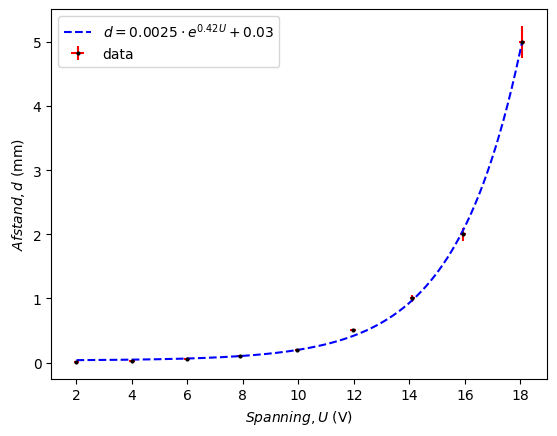

In [4]:
# Importeren van numpy en matplotlib library
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#--------data--------#
#Meetgegevens: afstand in milimeter, spanning in Volt
afstand = np.array([0.01,0.02,0.05,0.1,0.2,0.5,1.0,2.0,5.0])
spanning = np.array([2.01868928,4.01442631,5.99586649,7.91166258,9.96850493,11.96229652
                     ,14.1133456,15.93947672,18.04932637])
#onzekerheden meetgegevens:
u_V= 0.1 #V #de onzekerheid in de spanning meting
u_d= 0.05*afstand #mm #de onzekerheid in de afstand meting(5% van de meting)




#------curvefit------#
#functie:
def afstand_func(x,a,b,c):
    '''Exponentiele functie om mee te fitten want de data laat zo'n verband zien'''
    return a*np.exp(b*x)+c

#fitten:
val,cov=curve_fit(afstand_func,spanning,afstand) #least squares fit
a,b,c=val #de waarden voor a,b en c
u_a,u_b,u_c=np.sqrt(np.diag(cov)) #de onzekerheden in a,b en c
print("De waarden voor het exponentieel verband zijn bepaald op a = %.4f +/- %.4f, b = %.2f +/- %.2f en c = %.2f +/- %.2f" %(a,u_a,b,u_b,c,u_c))



#-------plotten-------#
x_plot=np.linspace(min(spanning),max(spanning),1000) #array om de beste fit mee te plotten met hetzelfde domein als de data
plt.figure()
plt.errorbar(spanning, afstand, xerr=u_V, yerr=u_d, fmt="k.", ecolor="r", ms=4, label="data") #plotten data met error
plt.plot(x_plot, afstand_func(x_plot,*val), "b--", label=r"$d=0.0025\cdot e^{0.42 U} + 0.03 $") #plotten van de beste fit
plt.ylabel("$Afstand,d$ (mm)")
plt.xlabel("$Spanning,U$ (V)")
plt.legend(loc="upper left")
plt.show()